<a href="https://colab.research.google.com/github/sadiksha1920/DSA/blob/master/day25word2vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Gensim is a python library for natural language Processing(NLP) , mainly used for topic modeling and word embeddings

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.7 MB/s eta 0:00:00


In [2]:
from gensim.models import Word2Vec
# Small sample corpus (already tokenized)
sentences = [
    ["i", "love", "nlp"],
    ["i", "love", "machine", "learning"],
    ["nlp", "is", "fun"],
    ["machine", "learning", "is", "powerful"]]

In [3]:
# Train Word2Vec model
model = Word2Vec(
    sentences,
    vector_size=50,   # size of word vectors
    window=2,         # context window size
    min_count=1)      # include all words

vector_size → embedding size window → context window size

In [4]:
#Get vector for a word
vector_nlp = model.wv["nlp"]
print("Vector for 'nlp':",vector_nlp)

Vector for 'nlp': [ 1.56351421e-02 -1.90203730e-02 -4.11062239e-04  6.93839323e-03
 -1.87794445e-03  1.67635437e-02  1.80215668e-02  1.30730132e-02
 -1.42324204e-03  1.54208085e-02 -1.70686692e-02  6.41421322e-03
 -9.27599426e-03 -1.01779103e-02  7.17923651e-03  1.07406788e-02
  1.55390287e-02 -1.15330126e-02  1.48667218e-02  1.32509926e-02
 -7.41960062e-03 -1.74912829e-02  1.08749345e-02  1.30195115e-02
 -1.57510047e-03 -1.34197120e-02 -1.41718509e-02 -4.99412045e-03
  1.02865072e-02 -7.33047491e-03 -1.87401194e-02  7.65347946e-03
  9.76895820e-03 -1.28571270e-02  2.41711619e-03 -4.14975407e-03
  4.88066689e-05 -1.97670180e-02  5.38400887e-03 -9.50021297e-03
  2.17529293e-03 -3.15244915e-03  4.39334614e-03 -1.57631524e-02
 -5.43436781e-03  5.32639725e-03  1.06933638e-02 -4.78302967e-03
 -1.90201886e-02  9.01175756e-03]


In [5]:
#Find similar words
similar_words = model.wv.most_similar("nlp")
print("word similar to 'nlp':",similar_words)

word similar to 'nlp': [('fun', 0.0449172779917717), ('is', -0.014475265517830849), ('powerful', -0.04407211393117905), ('machine', -0.15515565872192383), ('learning', -0.17424817383289337), ('love', -0.20600517094135284), ('i', -0.2091004103422165)]


“We are not training Word2Vec to predict words — we train it to get good word vectors.”

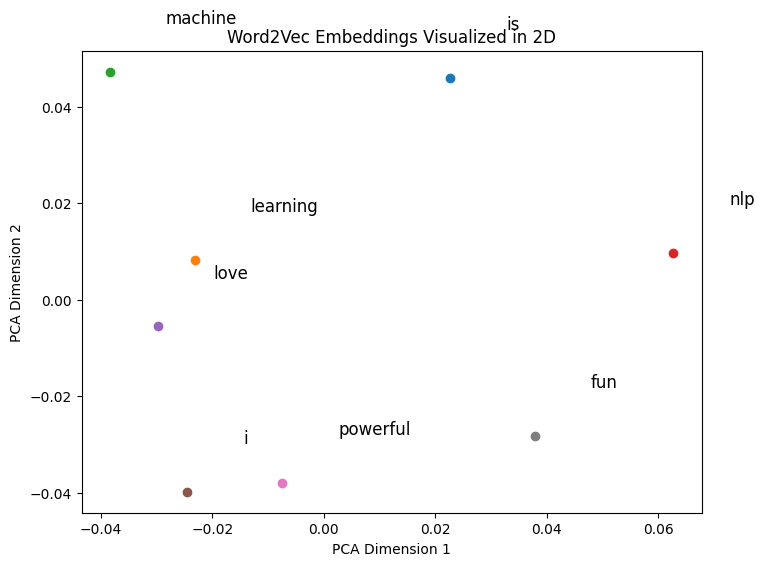

In [11]:
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Train Word2Vec model (CBOW by default)
model = Word2Vec(sentences, vector_size=50, window=2, min_count=1)

# Get all words in the vocabulary
words = list(model.wv.index_to_key)

# Get vectors for all words
word_vectors = [model.wv[word] for word in words]

# Reduce dimensions to 2D using PCA
pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)

# Plot
plt.figure(figsize=(8,6))
for i, word in enumerate(words):
    x, y = word_vectors_2d[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word, fontsize=12)
plt.title("Word2Vec Embeddings Visualized in 2D")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.show()

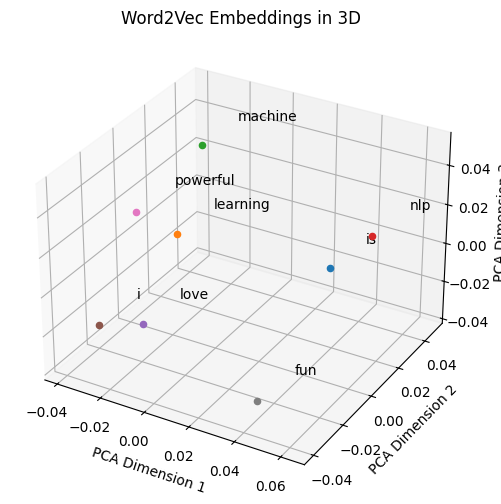

In [12]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plots
# Train Word2Vec model
model = Word2Vec(sentences, vector_size=50, window=2, min_count=1, sg=1)
# Get all words in vocabulary
words = list(model.wv.index_to_key)
# Get vectors for all words
word_vectors = [model.wv[word] for word in words]
# Reduce dimensions to 3D using PCA
pca = PCA(n_components=3)
word_vectors_3d = pca.fit_transform(word_vectors)
# Plot in 3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
for i, word in enumerate(words):
    x, y, z = word_vectors_3d[i]
    ax.scatter(x, y, z)
    ax.text(x+0.01, y+0.01, z+0.01, word, fontsize=10)

ax.set_title("Word2Vec Embeddings in 3D")
ax.set_xlabel("PCA Dimension 1")
ax.set_ylabel("PCA Dimension 2")
ax.set_zlabel("PCA Dimension 3")
plt.show()


CBOW

In [13]:
import tensorflow as tf
import numpy as np

#DATA
text = "i love deep learning and i love machine learning"
tokens = text.split()

vocab = sorted(set(tokens))
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}

vocab_size = len(vocab)
window_size = 2

# CBOW DATA
def make_cbow_data(tokens, window):
    X, y = [], []

    for i in range(window, len(tokens)-window):
        context = []

        for j in range(-window, window+1):
            if j != 0:
                context.append(word2idx[tokens[i+j]])

        target = word2idx[tokens[i]]

        X.append(context)
        y.append(target)

    return np.array(X), np.array(y)

X, y = make_cbow_data(tokens, window_size)

# CBOW MODEL
embedding_dim = 10

class CBOW(tf.keras.Model):
    def __init__(self):
        super().__init__()

        self.embedding = tf.keras.layers.Embedding(
            vocab_size, embedding_dim
        )

        self.output_layer = tf.keras.layers.Dense(vocab_size)

    def call(self, x):
        x = self.embedding(x)           # embed context words
        x = tf.reduce_mean(x, axis=1)   # average context vectors
        x = self.output_layer(x)        # predict center word
        return x

model = CBOW()

model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
)

model.fit(X, y, epochs=300, verbose=0)

embeddings_cbow = model.embedding.get_weights()[0]

In [14]:
context_words = ["i", "deep", "learning", "and"]

context_ids = np.array([[word2idx[w] for w in context_words]])

logits = model(context_ids)
pred_id = tf.argmax(logits, axis=1).numpy()[0]

print("Predicted word:", idx2word[pred_id])

Predicted word: and


In [15]:
embeddings = model.embedding.get_weights()[0]

print("Vector for 'learning':")
print(embeddings[word2idx["learning"]])

Vector for 'learning':
[-4.8822153e-01  3.3630705e-01 -1.6927153e-02  5.2670461e-01
 -4.3248981e-02 -1.7801404e-01  2.4940952e-04 -1.8143827e-01
  4.9594380e-02 -3.7176244e-02]


In [16]:
from sklearn.metrics.pairwise import cosine_similarity

word = "learning"
vec = embeddings[word2idx[word]].reshape(1, -1)

similarity = cosine_similarity(vec, embeddings)

for i in similarity.argsort()[0][-5:][::-1]:
    print(idx2word[i], similarity[0][i])

learning 1.0000002
machine 0.5986114
i 0.1763938
and -0.0152277965
love -0.15897256


Skipgram

In [17]:
import tensorflow as tf
import numpy as np

#  DATA
text = "i love deep learning and i love machine learning"
tokens = text.split()

vocab = sorted(set(tokens))
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}

vocab_size = len(vocab)
window_size = 2

# SKIPGRAM DATA
def make_skipgram_data(tokens, window):
    X, y = [], []

    for i in range(window, len(tokens)-window):
        center = word2idx[tokens[i]]

        for j in range(-window, window+1):
            if j != 0:
                context = word2idx[tokens[i+j]]
                X.append(center)
                y.append(context)

    return np.array(X), np.array(y)

X, y = make_skipgram_data(tokens, window_size)

# SKIPGRAM MODEL
embedding_dim = 10

class SkipGram(tf.keras.Model):
    def __init__(self):
        super().__init__()

        self.embedding = tf.keras.layers.Embedding(
            vocab_size, embedding_dim
        )

        self.output_layer = tf.keras.layers.Dense(vocab_size)

    def call(self, x):
        x = self.embedding(x)      # embed center word
        x = self.output_layer(x)   # predict context word
        return x

model = SkipGram()

model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
)

model.fit(X, y, epochs=300, verbose=0)

embeddings_skipgram = model.embedding.get_weights()[0]

In [18]:
center_word = "love"

center_id = np.array([word2idx[center_word]])

logits = model(center_id)
pred_id = tf.argmax(logits, axis=1).numpy()[0]

print("Predicted context:", idx2word[pred_id])

Predicted context: and


In [19]:
#Word vectors
embeddings = model.embedding.get_weights()[0]

print("Vector for 'love':")
print(embeddings[word2idx["love"]])

Vector for 'love':
[ 0.06262325 -0.4103932  -0.01266429  0.05402551  0.0806573   0.05039859
  0.38264456 -0.03533499 -0.01426701 -0.18802243]


In [20]:
#Similarity
from sklearn.metrics.pairwise import cosine_similarity

word = "love"
vec = embeddings[word2idx[word]].reshape(1, -1)

similarity = cosine_similarity(vec, embeddings)

for i in similarity.argsort()[0][-5:][::-1]:
    print(idx2word[i], similarity[0][i])

love 1.0000001
deep 0.5447103
i 0.3300318
machine 0.08577278
learning -0.35941464


In [21]:
from gensim.models import Word2Vec

# Sample corpus (assuming 'sentences' is defined elsewhere as in previous cells)
sentences = [
    ["i", "love", "nlp"],
    ["i", "love", "machine", "learning"],
    ["nlp", "is", "fun"],
    ["machine", "learning", "is", "powerful"]
]

# CBOW model (Continuous Bag of Words) - this is the default
cbow_model = Word2Vec(
    sentences,
    vector_size=50,   # size of word vectors
    window=2,         # context window size
    min_count=1,      # include all words
    sg=0              # 0 for CBOW (default)
)

print("CBOW Model created.")

# Skip-gram model
skipgram_model = Word2Vec(
    sentences,
    vector_size=50,   # size of word vectors
    window=2,         # context window size
    min_count=1,      # include all words
    sg=1              # 1 for Skip-gram
)

print("Skip-gram Model created.")

# You can then use these models, e.g.,
# print("Vector for 'nlp' (CBOW):", cbow_model.wv["nlp"])
# print("Vector for 'nlp' (Skip-gram):", skipgram_model.wv["nlp"])

CBOW Model created.
Skip-gram Model created.
